# 4. Ultrasoft and PAW pseudopotentials

Everything up to here used **norm-conserving** pseudopotentials, where the pseudo
orbital carries exactly as much charge inside the core as the all-electron one it
replaces. That constraint is what makes `<psi|psi> = 1` the normalisation, `|psi(r)|^2`
the density, and the Kohn-Sham problem an ordinary eigenvalue problem. It is also
expensive: forcing the norm to match makes the pseudo orbital wiggle, and wiggles cost
plane waves. Silicon needs `ecutwfc = 12` Ry with `Si.pz-vbc`; oxygen or a transition
metal needs 80 or more.

**Ultrasoft** pseudopotentials (Vanderbilt) drop the constraint and repair the damage
explicitly. **PAW** (Bloechl) goes further and repairs it *exactly*, by recomputing the
parts of the energy the smooth grid gets wrong on each atom's own radial mesh.

This notebook follows what changes, in the order the code had to change it:

1. two FFT grids instead of one, and why;
2. the augmentation charge `Q_ij(r)`, and what it does to the density;
3. the overlap operator `S`, and the generalised eigenproblem it creates;
4. the `D_ij` coefficients, which stop being constants;
5. PAW's one-centre terms;
6. every energy against Quantum ESPRESSO, and the timing.

Everything is LDA (Perdew-Zunger), on the same silicon the earlier notebooks use, with
the `pz` ultrasoft and PAW datasets from PSlibrary.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pypresso.basis.builder import build_basis
from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system

CASES = Path('../tests/data/qe')
PSEUDO = Path('../tests/data/pseudo')

def load(case):
    system = build_system(read_pw_input(CASES / f'{case}.in'))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos

def reference(case):
    return read_qe_output(CASES / f'reference.out.{case}')

nc = read_upf(PSEUDO / 'Si.pz-vbc.UPF')
us = read_upf(PSEUDO / 'Si.pz-n-rrkjus_psl.0.1.UPF')
paw = read_upf(PSEUDO / 'Si.pz-n-kjpaw_psl.0.1.UPF')

for p in (nc, us, paw):
    print(f'{p.path.name:32s} {p.pseudo_type:5s} ultrasoft={p.is_ultrasoft!s:5s} '
          f'PAW={p.is_paw!s:5s} projectors={[b.l for b in p.projectors]} nh={p.nh}')

Si.pz-vbc.UPF                    NC    ultrasoft=False PAW=False projectors=[0, 1] nh=4
Si.pz-n-rrkjus_psl.0.1.UPF       USPP  ultrasoft=True  PAW=False projectors=[0, 0, 1, 1] nh=8
Si.pz-n-kjpaw_psl.0.1.UPF        PAW   ultrasoft=True  PAW=True  projectors=[0, 0, 1, 1] nh=8


`pseudo_type` is free text, and the generators disagree about it: the `atomic` code
writes `USPP` where the format documentation says `US`. Matching only `US` reads a
perfectly good ultrasoft file as norm-conserving, which is not an error anywhere — just
a calculation with the augmentation charge silently missing and an energy wrong in the
first decimal. `is_ultrasoft` accepts every spelling.

## 1. Two grids

The augmentation charge (next section) is sharply peaked — it is the *difference*
between an all-electron and a pseudo orbital, so it lives entirely inside the core
radius. Representing it needs a much denser Fourier grid than the wavefunctions do.
QE's answer, and now this code's, is to keep two:

- the **smooth** grid, out to `4*ecutwfc`, for wavefunctions and everything built from
  them;
- the **dense** grid, out to `ecutrho`, for the density, the potential and the
  augmentation charge.

A norm-conserving run has `ecutrho = 4*ecutwfc` and the two coincide, which is why they
never had to be separated before.

In [2]:
system, pseudos = load('si2-us')
basis = build_basis(system)
ref = reference('si2-us')

print(f'dual = ecutrho/ecutwfc = {system.ecutrho / system.ecutwfc:g}')
print()
print(f'{"":8s} {"ours":>26s}   {"Quantum ESPRESSO":>26s}')
print(f'{"dense":8s} {basis.dense.ngm:6d} G  FFT {basis.dense.grid!s:>14s}   '
      f'{ref.ngm_dense:6d} G  FFT {ref.fft_dense!s:>14s}')
print(f'{"smooth":8s} {basis.smooth.ngm:6d} G  FFT {basis.smooth.grid!s:>14s}   '
      f'{ref.ngm_smooth:6d} G  FFT {ref.fft_smooth!s:>14s}')
print(f'{"wfc":8s} npw = {basis.planewaves.npw}')

# The smooth set is a *prefix* of the dense one -- both are sorted by |G|^2, so the
# vectors inside the smaller sphere are the first ngms entries of the larger list.
# That is what makes moving a field between the grids a slice one way and a zero-pad
# the other, rather than a search for matching Miller indices.
same = np.array_equal(np.asarray(basis.smooth.miller),
                      np.asarray(basis.dense.miller)[: basis.smooth.ngm])
print(f'\nsmooth G-vectors are the first {basis.smooth.ngm} dense ones: {same}')

dual = ecutrho/ecutwfc = 8

                               ours             Quantum ESPRESSO
dense      9185 G  FFT   (32, 32, 32)     9185 G  FFT   (32, 32, 32)
smooth     3143 G  FFT   (24, 24, 24)     3143 G  FFT   (24, 24, 24)
wfc      npw = (395, 404)

smooth G-vectors are the first 3143 dense ones: True


### An aside that cost a day: the FFT grid is not set by the cutoff alone

Diamond silicon is non-symmorphic — half its symmetry operations combine a rotation
with a translation of a quarter of a lattice vector — and a grid only maps onto itself
under a translation of `1/4` if it has a multiple of 4 points along that axis. QE
therefore forces the FFT dimensions to be a multiple of the denominators of the
fractional translations (`fft_fact` in `symm_base.f90`).

The cutoff alone would give 30³ here; QE gives 32³. That is not cosmetic: the
exchange-correlation energy is evaluated pointwise on the grid, so a different grid is a
different `etxc` in the sixth decimal — worth ~1e-6 Ry, which is a hundred times the
agreement this project holds itself to.

There is a second rule stacked on top. If the identity combined with some non-lattice
translation already maps the structure onto itself, the cell is a *supercell*, and QE
disables fractional translations entirely. The eight-atom cubic cell of silicon is one:
QE keeps 24 operations rather than 48 and drops the divisibility constraint with them.

In [3]:
from pypresso.system.symmetry import find_symmetries, is_supercell

for case in ('si2-us', 'si8-us'):
    s, _ = load(case)
    sym = find_symmetries(s.cell, s.structure)
    b = build_basis(s)
    r = reference(case)
    print(f'{case}: {s.structure.nat} atoms, supercell={is_supercell(s.cell, s.structure)!s:5s} '
          f'nsym={sym.nsym:2d}  fft_fact={sym.fft_factors()}')
    print(f'          dense grid {b.dense.grid} vs QE {r.fft_dense};  '
          f'smooth {b.smooth.grid} vs QE {r.fft_smooth}')

si2-us: 2 atoms, supercell=False nsym=48  fft_fact=(4, 4, 4)
          dense grid (32, 32, 32) vs QE (32, 32, 32);  smooth (24, 24, 24) vs QE (24, 24, 24)
si8-us: 8 atoms, supercell=True  nsym=24  fft_fact=(1, 1, 1)
          dense grid (45, 45, 45) vs QE (45, 45, 45);  smooth (30, 30, 30) vs QE (30, 30, 30)


## 2. The augmentation charge

Where the norm no longer matches, the missing charge is put back explicitly:

$$Q_{ij}(\mathbf r) = \phi_i^{AE*}(\mathbf r)\,\phi_j^{AE}(\mathbf r)
 - \phi_i^{PS*}(\mathbf r)\,\phi_j^{PS}(\mathbf r)$$

and the density becomes

$$\rho(\mathbf r) = \sum_{k,b} w_{kb}\,|\psi_{kb}(\mathbf r)|^2
 + \sum_{a,ij} \rho^a_{ij}\, Q^a_{ij}(\mathbf r)$$

where $\rho^a_{ij} = \sum_{kb} w_{kb}\langle\psi|\beta_i^a\rangle\langle\beta_j^a|\psi\rangle$
is QE's `becsum`. The file tabulates $Q$ radially, resolved into multipoles
$Q^L_{ij}(r)$; getting it onto the grid means a spherical Bessel transform and a
resolution of the product $Y_{l_i m_i} Y_{l_j m_j}$ back into harmonics.

The first check is free and sharp: $\Omega\,Q_{ij}(G{=}0)$ must reproduce the `PP_Q`
block the file tabulates *separately*, written by the generator rather than derived from
$Q^L_{ij}(r)$.

In [4]:
from pypresso.pseudo.augmentation import build_augmentation
from pypresso.pseudo.projectors import projector_channels

system, pseudos = load('si2-us')
basis = build_basis(system)
aug = build_augmentation(pseudos, system.structure, system.cell, basis.dense)

channels = projector_channels(pseudos[0])
expected = np.zeros((len(channels), len(channels)))
for i, (nb_i, _, lm_i) in enumerate(channels):
    for j, (nb_j, _, lm_j) in enumerate(channels):
        if lm_i == lm_j:
            expected[i, j] = pseudos[0].augmentation.q[nb_i, nb_j]

qq = np.asarray(aug.qq[0])
print('Omega * Q_ij(G=0), diagonal:', np.round(np.diag(qq), 8))
print('PP_Q from the file        :', np.round(np.diag(expected), 8))
print(f'max difference: {np.abs(qq - expected).max():.2e}  '
      '(the file\'s own two tabulations agree only this well)')

Omega * Q_ij(G=0), diagonal: [-0.18793584 -1.04846795 -0.02932243 -0.02932243 -0.02932243 -0.09353223
 -0.09353223 -0.09353223]
PP_Q from the file        : [-0.18793579 -1.04846848 -0.0293224  -0.0293224  -0.0293224  -0.09353221
 -0.09353221 -0.09353221]
max difference: 5.30e-07  (the file's own two tabulations agree only this well)


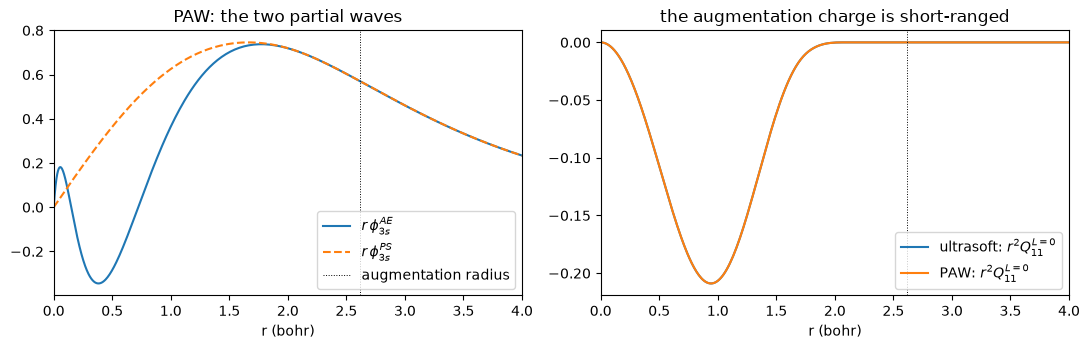

In [5]:
# Q_ij(r) itself: the two partial waves and their difference, for the first s channel.
p = pseudos[0]
iraug = paw.paw.cutoff_index
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

r = paw.r
axes[0].plot(r, paw.paw.ae_wfc[0], label=r'$r\,\phi^{AE}_{3s}$')
axes[0].plot(r, paw.paw.ps_wfc[0], label=r'$r\,\phi^{PS}_{3s}$', ls='--')
axes[0].axvline(r[iraug - 1], color='k', lw=0.7, ls=':', label='augmentation radius')
axes[0].set_xlim(0, 4); axes[0].set_xlabel('r (bohr)'); axes[0].legend()
axes[0].set_title('PAW: the two partial waves')

for label, pp in (('ultrasoft', us), ('PAW', paw)):
    axes[1].plot(pp.r, pp.augmentation.qfuncl[0, 0, 0], label=f'{label}: $r^2Q^{{L=0}}_{{11}}$')
axes[1].axvline(r[iraug - 1], color='k', lw=0.7, ls=':')
axes[1].set_xlim(0, 4); axes[1].set_xlabel('r (bohr)'); axes[1].legend()
axes[1].set_title('the augmentation charge is short-ranged')
plt.tight_layout(); plt.show()

The augmentation charge vanishes outside the augmentation radius — that locality is
what makes the whole scheme work, and it is why the dense grid only has to be dense,
not large.

## 3. The overlap operator, and the identity it guarantees

Integrating $Q_{ij}$ gives $q_{ij}$, and with it the overlap operator

$$S = 1 + \sum_{a,ij} |\beta^a_i\rangle\, q^a_{ij}\, \langle\beta^a_j|$$

so the Kohn-Sham problem becomes $H\psi = \varepsilon S \psi$. Davidson, the
Rayleigh-Ritz step that builds the starting wavefunctions, and the preconditioner all
had to learn about it.

The payoff is a check that costs nothing and is *exact* rather than approximate. A state
is normalised as $\langle\psi|S|\psi\rangle = 1$, and the part of that norm which $S$
supplies is precisely the augmentation charge's integral — so
$\int\rho\,d^3r = N_{\text{elec}}$ holds identically, to round-off, provided the
$q_{ij}$ in $S$ and the $Q_{ij}(G{=}0)$ in the density are the same numbers. If the
projector bookkeeping or the `becsum` packing were wrong, this would fail immediately.

In [6]:
results = {}
for case in ('si2-nc-dual8', 'si2-us', 'si2-paw', 'si8-us', 'si8-paw'):
    s, ps = load(case)
    results[case] = (s, ps, run_scf(s, ps, conv_thr=1e-10, max_iterations=80))

print(f'{"case":16s} {"iters":>5s} {"int rho":>14s} {"nelec":>7s}')
for case, (s, ps, r) in results.items():
    nelec = sum(ps[t].z_valence for t in s.structure.types)
    charge = float(np.sum(np.asarray(r.density))) * float(s.cell.volume) / r.density.size
    print(f'{case:16s} {r.iterations:5d} {charge:14.12f} {nelec:7.1f}')

case             iters        int rho   nelec
si2-nc-dual8         7 8.000000000000     8.0
si2-us               9 8.000000000000     8.0
si2-paw              8 8.000000000000     8.0
si8-us              10 32.000000000000    32.0
si8-paw              8 32.000000000000    32.0


## 4. `D_ij` stops being a constant

For a norm-conserving potential the nonlocal coefficients are read from the file once
and never touched again. With an augmentation charge they acquire a term that depends on
the potential, and therefore on the atom and on the SCF iteration:

$$D^a_{ij} = D^{(0)}_{ij} + \int V_{\text{eff}}(\mathbf r)\, Q^a_{ij}(\mathbf r)\,d^3r$$

This is QE's `newd`, and it runs once per iteration on the dense grid. Watching it
converge alongside the density is a good way to see that it really is part of the
self-consistency, not a setup step.

In [7]:
case = 'si2-us'
s, ps = load(case)
calc = Calculation(s, ps)

history = []
original = calc.coefficients
def spy(potential, ddd_paw=None):
    d = original(potential, ddd_paw)
    history.append(np.asarray(d).copy())
    return d
calc.coefficients = spy
r = run_scf(s, ps, conv_thr=1e-10, calculation=calc)

d0 = np.asarray(calc.projectors.dij)
print('D^(0) from the file (first 4x4 block, Ry):')
print(np.round(d0[:4, :4], 6))
print()
print('converged D (same block):')
print(np.round(history[-1][:4, :4], 6))
print()
for i, d in enumerate(history, 1):
    print(f'  iteration {i:2d}: max |D - D_converged| = '
          f'{np.abs(d - history[-1]).max():.2e} Ry')

D^(0) from the file (first 4x4 block, Ry):
[[ 0.635167  0.208822  0.        0.      ]
 [ 0.208822 -3.053116  0.        0.      ]
 [ 0.        0.        0.240817  0.      ]
 [ 0.        0.        0.        0.240817]]

converged D (same block):
[[ 1.744154  3.272926  0.        0.      ]
 [ 3.272926  5.793208  0.       -0.      ]
 [ 0.        0.        0.337418 -0.      ]
 [ 0.       -0.       -0.        0.337418]]

  iteration  1: max |D - D_converged| = 4.63e-02 Ry
  iteration  2: max |D - D_converged| = 1.26e-02 Ry
  iteration  3: max |D - D_converged| = 5.55e-03 Ry
  iteration  4: max |D - D_converged| = 1.61e-03 Ry
  iteration  5: max |D - D_converged| = 3.47e-04 Ry
  iteration  6: max |D - D_converged| = 7.21e-05 Ry
  iteration  7: max |D - D_converged| = 1.45e-05 Ry
  iteration  8: max |D - D_converged| = 8.25e-06 Ry
  iteration  9: max |D - D_converged| = 0.00e+00 Ry


## 5. PAW's one-centre terms

PAW is ultrasoft plus one more idea. The smooth grid still cannot represent what happens
inside the augmentation sphere, so PAW computes the Hartree and exchange-correlation
energy there *twice* on the atom's own radial mesh — once from the all-electron partial
waves and once from the pseudo ones — and adds the difference:

$$E = E[\tilde\rho \text{ on the grid}] + \sum_a\big(E_{Hxc}[\rho^1_a] - E_{Hxc}[\tilde\rho^1_a]\big)$$

QE prints that sum as its own energy term, which makes it directly checkable. Two pieces
of machinery are needed that nothing else in the code uses: a radial Poisson solver and
a spherical quadrature.

The Poisson solver is transcribed from `upflib/radial_grids.f90` rather than replaced by
the closed-form integral, and deliberately so — the one-centre energy has to agree with
QE's to ~1e-8 *relative*, and two different discretisations of the same integral do not
agree to 1e-8 while the same discretisation does trivially. It is a Numerov scheme on
the logarithmic mesh, i.e. a tridiagonal solve. Against an analytic test case:

In [8]:
from jax.scipy.special import gammainc  # noqa: F401  (scipy is used below)
from scipy.special import gamma, gammainc, gammaincc
import jax.numpy as jnp
from pypresso.paw.hartree import radial_hartree
from pypresso.units import E2, FPI

rr = jnp.asarray(paw.r); r2 = rr**2; sqr = jnp.sqrt(rr); rn = np.asarray(paw.r)
print('multipole   max |numerov - analytic| / max|analytic|')
for l in (0, 1, 2, 3):
    f = rn**(2*l+2) * np.exp(-2.0*rn)          # r^2 rho_l, ~ r^(2l+2) at the origin
    v = np.asarray(radial_hartree(E2*FPI/(2*l+1)*jnp.asarray(f), rr, r2, sqr,
                                  paw.dx, l, 2*l+2))
    n, m = 3*l+2, l+1
    inner = 2.0**-(n+1) * gamma(n+1) * gammainc(n+1, 2*rn)
    outer = 2.0**-(m+1) * gamma(m+1) * gammaincc(m+1, 2*rn)
    exact = E2*FPI/(2*l+1) * (inner/rn**(l+1) + rn**l * outer)
    mask = rn < 30.0
    print(f'   l = {l}    {np.abs(v[mask]-exact[mask]).max()/np.abs(exact[mask]).max():.1e}')

multipole   max |numerov - analytic| / max|analytic|
   l = 0    1.2e-10
   l = 1    1.1e-09
   l = 2    3.0e-09
   l = 3    5.6e-09


Exchange and correlation cannot be done multipole by multipole — `e_xc` is not linear —
so the density is put back onto the sphere, the functional evaluated pointwise, and the
result projected back. The quadrature is a product rule: Gauss-Legendre in
$\cos\theta$ times equally spaced $\phi$, exact for harmonics up to `3 * lmax_rho`,
which for silicon is 28 directions.

### The trap: `becsum` has to be symmetrised by hand

The density on the grid is symmetrised in G space, which covers the augmentation charge
too. `becsum` is not covered by that — PAW feeds it to the radial machinery directly,
where the crystal's symmetry has no grid to act on. With a symmetry-reduced k-point set
it comes out **anisotropic**, and silicon's three `p` channels, which symmetry says must
be equal, are not:

In [9]:
from pypresso.paw.symmetry import build_becsum_symmetry

s, ps = load('si2-paw')
calc = Calculation(s, ps)
r = run_scf(s, ps, conv_thr=1e-10, calculation=calc)

raw = calc._becsum_symmetry
calc._becsum_symmetry = None
unsymmetrised = np.asarray(calc.becsum(r.wavefunctions, r.occupations)[0][0])
calc._becsum_symmetry = raw
symmetrised = np.asarray(calc.becsum(r.wavefunctions, r.occupations)[0][0])

labels = [f'n={nb+1} l={l} m={lm-l*l}' for nb, l, lm in projector_channels(ps[0])]
print(f'{"channel":14s} {"as computed":>13s} {"symmetrised":>13s}')
for k, label in enumerate(labels):
    print(f'{label:14s} {unsymmetrised[k, k]:13.8f} {symmetrised[k, k]:13.8f}')
print()
print('The three l=1 channels must be equal by cubic symmetry. Before symmetrisation')
print(f'they span {unsymmetrised[2,2]:.6f} .. {unsymmetrised[3,3]:.6f}; after, they agree to '
      f'{abs(symmetrised[2,2]-symmetrised[4,4]):.1e}.')

channel          as computed   symmetrised
n=1 l=0 m=0       1.55313875    1.55313875
n=2 l=0 m=0       0.00172111    0.00172111
n=3 l=1 m=0       1.00335726    1.17977242
n=3 l=1 m=1       1.26797999    1.17977242
n=3 l=1 m=2       1.26797999    1.17977242
n=4 l=1 m=0       0.00212297    0.00171822
n=4 l=1 m=1       0.00151585    0.00171822
n=4 l=1 m=2       0.00151585    0.00171822

The three l=1 channels must be equal by cubic symmetry. Before symmetrisation
they span 1.003357 .. 1.267980; after, they agree to 4.4e-16.


Symmetrising `becsum` is the difference between agreeing with QE's one-centre energy to
3e-5 Ry and to 2e-10 Ry. It needs the matrices that mix real spherical harmonics under
each operation — computed here the same way the Gaunt coefficients are, by evaluating
the harmonics at rotated directions and inverting, so that they cannot disagree with the
harmonics they are defined against.

## 6. Against Quantum ESPRESSO

The references were generated once with the vendored serial `pw.x`
(`tools/generate_reference.py`) — no committed benchmark covers these pseudopotentials —
at `conv_thr = 1e-10` on both sides, so the two codes stop at the same fixed point and
the *terms* are comparable, not only the variational total.

In [10]:
print(f'{"case":16s} {"pypresso (Ry)":>16s} {"QE 7.5 (Ry)":>16s} {"difference":>12s}')
for case, (s, ps, r) in results.items():
    q = reference(case)
    print(f'{case:16s} {r.total_energy:16.8f} {q.total_energy:16.8f} '
          f'{r.total_energy - q.total_energy:12.1e}')

case                pypresso (Ry)      QE 7.5 (Ry)   difference
si2-nc-dual8         -15.79449489     -15.79449489     -9.2e-10
si2-us               -22.75348130     -22.75348130     -2.4e-09
si2-paw              -89.27493665     -89.27493665     -2.9e-09
si8-us               -91.01392589     -91.01392589      5.0e-10
si8-paw             -357.09973538    -357.09973538     -2.3e-09


In [11]:
case = 'si2-paw'
s, ps, r = results[case]
q = reference(case)
print(f'{case}, term by term:\n')
print(f'{"term":18s} {"pypresso (Ry)":>16s} {"QE 7.5 (Ry)":>16s} {"difference":>12s}')
for term, value in q.energy_terms.items():
    print(f'{term:18s} {r.energy_terms[term]:16.8f} {value:16.8f} '
          f'{r.energy_terms[term] - value:12.1e}')
print(f'{"TOTAL":18s} {r.total_energy:16.8f} {q.total_energy:16.8f} '
      f'{r.total_energy - q.total_energy:12.1e}')
print()
print('The one-centre term is 75% of the total here, and most of *it* is a constant:')
print('the exchange-correlation energy of the frozen core, which the pseudopotential')
print('file fixes and no calculation changes.')

si2-paw, term by term:

term                  pypresso (Ry)      QE 7.5 (Ry)   difference
one-electron             5.90316626       5.90316889     -2.6e-06
hartree                  1.09671862       1.09671431      4.3e-06
xc                     -12.19555356     -12.19555167     -1.9e-06
ewald                  -16.89975860     -16.89975860     -2.1e-09
one_center_paw         -67.17950937     -67.17950958      2.1e-07
TOTAL                  -89.27493665     -89.27493665     -2.9e-09

The one-centre term is 75% of the total here, and most of *it* is a constant:
the exchange-correlation energy of the frozen core, which the pseudopotential
file fixes and no calculation changes.


In [12]:
# Eigenvalues, where QE prints them (4 decimals in eV, so that is the resolution).
for case in ('si2-us', 'si2-paw'):
    s, ps, r = results[case]
    q = reference(case)
    theirs = q.eigenvalues[0][:, : r.eigenvalues.shape[1]]
    print(f'{case}: max |pypresso - QE| = '
          f'{np.abs(r.eigenvalues_ev - theirs).max()*1000:.3f} meV over '
          f'{theirs.size} eigenvalues')

si2-us: max |pypresso - QE| = 0.053 meV over 8 eigenvalues
si2-paw: max |pypresso - QE| = 0.041 meV over 8 eigenvalues


### What it costs

The measurement is single-core pypresso against single-core Quantum ESPRESSO on the
same input (`tools/compare_qe.py`; the full discussion is in `PERFORMANCE.md`). At
`ecutwfc = 20`, `ecutrho = 160`, one k-point:

| | QE 7.5 | pypresso | ratio |
|---|---|---|---|
| `si2-us-1k` — 2 atoms | 0.024 s | 0.051 s | **2.2x** |
| `si2-paw-1k` — 2 atoms, PAW | 0.044 s | 0.080 s | **1.8x** |
| `si8-us-1k` — 8 atoms | 0.124 s | 0.355 s | **2.9x** |
| `si8-paw-1k` — 8 atoms, PAW | 0.172 s | 0.477 s | **2.8x** |

per SCF iteration. That is the same 2–4x band the norm-conserving path sits in, which is
the interesting part: ultrasoft adds a great deal of work — an augmentation charge built
on a 45³ grid every iteration, nonlocal coefficients rebuilt from the potential, an
interpolation between two grids — but all of it is dense array work, which is what XLA
is good at. PAW's one-centre terms are the opposite: many small radial solves, where
dispatch dominates and batching is worth more than arithmetic. Grouping the multipoles
into one batched Poisson solve took the eight-atom PAW cell from 3.0x to 2.8x.

### What is not covered

- **LDA only.** The `pz` datasets are used deliberately: PBE would need GGA on the
  plane-wave grid *and* on the PAW radial grids, which is a separate piece of work.
- **`q_with_l = F` files are refused, not guessed at.** The pre-2.0 format stores one
  `Q_ij(r)` per pair plus polynomial coefficients that re-pseudize it inside an inner
  radius; reading the tabulated `Q` without applying that gives a subtly wrong
  augmentation charge, so the reader raises instead.
- **Gamma-only with ultrasoft is refused** for the same reason: the half-sphere sums
  need QE's pair-doubling, which is not written, and nothing in the reference set would
  have caught it.
- **`nspin = 2`** is not implemented for any pseudopotential kind yet (P9).